In [32]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
target_col = "BU_TotActPwr_Tech_Room"
start_forecast_date = pd.to_datetime("2026-04-20").date()

prediction_files = sorted(pred_dir.glob(f"*{target_col}*profile_predictions.csv"))

print("Candidate files found:", len(prediction_files))


def detect_model_name(file_name):
    name = file_name.lower()

    if "random_forest" in name:
        return "random_forest"
    if "xgboost" in name:
        return "xgboost"
    if "catboost" in name:
        return "catboost"
    if "ridge" in name:
        return "ridge"
    if "linear_regression" in name:
        return "linear_regression"

    return "unknown"


def detect_resolution_from_horizons(n_horizons):
    if n_horizons == 96:
        return "15min", 0.25, 23, 45
    if n_horizons == 48:
        return "30min", 0.5, 23, 30
    if n_horizons == 24:
        return "60min", 1.0, 23, 0

    return "unknown", np.nan, None, None


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def sort_horizon_columns(cols):
    """
    Sort horizon columns by number, not alphabetically.
    This prevents wrong order like 1, 10, 11, ..., 2, 20.
    """
    def horizon_number(col):
        # examples:
        # y_tplus_001_true
        # y_tplus_1_true
        parts = col.replace("_true", "").replace("_pred", "").split("_")
        nums = [p for p in parts if p.isdigit()]
        return int(nums[-1]) if nums else 999999

    return sorted(cols, key=horizon_number)

Candidate files found: 57


In [33]:
rows = []
kept_files = []
skipped_files = []
bad_profile_rows = []

for file in prediction_files:
    model_name = detect_model_name(file.name)

    if model_name == "unknown":
        skipped_files.append((file.name, "unknown model name"))
        continue

    df = pd.read_csv(file)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sort_horizon_columns([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    if len(true_cols) == 0:
        skipped_files.append((file.name, "no true columns"))
        continue

    missing_pred_cols = [c for c in pred_cols if c not in df.columns]
    if missing_pred_cols:
        skipped_files.append((file.name, "missing pred columns"))
        continue

    n_horizons = len(true_cols)
    resolution, dt_hours, expected_issue_hour, expected_issue_minute = detect_resolution_from_horizons(n_horizons)

    if resolution == "unknown":
        skipped_files.append((file.name, f"unknown horizon count: {n_horizons}"))
        continue

    # Keep only correct issue time for that resolution
    issue_time_ok = (
        (df["issue_time"].dt.hour == expected_issue_hour) &
        (df["issue_time"].dt.minute == expected_issue_minute)
    )

    df = df[issue_time_ok].copy()

    if df.empty:
        skipped_files.append((file.name, f"wrong issue time for {resolution}"))
        continue

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    # Keep only forecast dates from 2026-04-20 onward
    df = df[df["forecast_date"] >= start_forecast_date].copy()

    if df.empty:
        skipped_files.append((file.name, "no forecast dates after start date"))
        continue

    # ------------------------------------------------------
    # Row-level quality filtering
    # ------------------------------------------------------
    good_rows = []

    for idx, r in df.iterrows():
        y_true_row = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
        y_pred_row = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

        valid = ~(np.isnan(y_true_row) | np.isnan(y_pred_row))

        # Require full horizon to be valid
        if valid.sum() != n_horizons:
            bad_profile_rows.append((file.name, r["forecast_date"], "incomplete horizon"))
            continue

        # Optional sanity check:
        # For this Tech Room load, a completely flat daily actual profile is suspicious.
        # This removes bad 60min runs that do not capture the daily operating pattern.
        actual_range = np.nanmax(y_true_row) - np.nanmin(y_true_row)
        actual_mean = np.nanmean(y_true_row)

        if actual_mean != 0:
            actual_range_ratio = actual_range / abs(actual_mean)
        else:
            actual_range_ratio = np.nan

        # If the day is almost flat, skip that row.
        # You can lower/raise 0.05 depending on your data.
        if actual_range_ratio < 0.05:
            bad_profile_rows.append((file.name, r["forecast_date"], "suspicious flat actual profile"))
            continue

        good_rows.append(idx)

    df_good = df.loc[good_rows].copy()

    if df_good.empty:
        skipped_files.append((file.name, "all rows failed quality filters"))
        continue

    y_true = df_good[true_cols].to_numpy(dtype=float).ravel()
    y_pred = df_good[pred_cols].to_numpy(dtype=float).ravel()

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        skipped_files.append((file.name, "no valid values after filtering"))
        continue

    errors = y_true - y_pred

    kept_files.append(file.name)

    rows.append({
        "file_name": file.name,
        "model_name": model_name,
        "target_col": target_col,
        "resolution": resolution,
        "dt_hours": dt_hours,

        "first_forecast_date": df_good["forecast_date"].min(),
        "last_forecast_date": df_good["forecast_date"].max(),
        "n_forecast_days": df_good["forecast_date"].nunique(),
        "n_issue_times": len(df_good),

        "n_horizon_steps": n_horizons,
        "n_values": len(y_true),

        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),

        "bias_actual_minus_pred": np.mean(errors),
        "error_std": np.std(errors),
    })


error_summary = pd.DataFrame(rows)

if not error_summary.empty:
    error_summary = error_summary.sort_values(
        ["resolution", "MAE"]
    ).reset_index(drop=True)

print("Files kept:", len(kept_files))
print("Files skipped:", len(skipped_files))
print("Bad profile rows:", len(bad_profile_rows))

display(error_summary)

Files kept: 20
Files skipped: 37
Bad profile rows: 0


,file_name,model_name,target_col,resolution,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,run_20260521_105037_ca9fc1b2_random_forest_BU_...,random_forest,BU_TotActPwr_Tech_Room,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.310727,0.572254,20.242668,0.838095,0.116292,0.560313
1,run_20260521_105150_d8cc6f68_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Tech_Room,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.319275,0.579373,20.778934,0.834042,0.108066,0.569206
2,run_20260521_104833_00ba167a_random_forest_BU_...,random_forest,BU_TotActPwr_Tech_Room,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.319768,0.596561,19.869577,0.824049,0.138983,0.580145
3,run_20260521_104832_8082fb66_ridge_BU_TotActPw...,ridge,BU_TotActPwr_Tech_Room,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.321286,0.628614,17.783375,0.804633,0.221230,0.588399
4,run_20260521_104947_e0cab5d9_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Tech_Room,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.324974,0.609934,20.227810,0.816072,0.135437,0.594707
5,run_20260521_105035_a8c7306e_ridge_BU_TotActPw...,ridge,BU_TotActPwr_Tech_Room,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.363775,0.641644,25.289390,0.796450,0.132735,0.627765
6,run_20260527_102550_662ba0ff_random_forest_BU_...,random_forest,BU_TotActPwr_Tech_Room,30min,0.50,2026-04-22,2026-04-30,9,9,48,432,0.287418,0.531768,18.337919,0.858043,0.106662,0.520961
7,run_20260527_102452_d1d61cc1_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Tech_Room,30min,0.50,2026-04-22,2026-04-30,9,9,48,432,0.290550,0.525509,18.268227,0.861365,0.115874,0.512575
8,run_20260527_102620_7a5b8ae8_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Tech_Room,30min,0.50,2026-04-22,2026-04-30,9,9,48,432,0.293162,0.537646,18.644292,0.854887,0.101354,0.528007
9,run_20260527_102424_1827ee81_random_forest_BU_...,random_forest,BU_TotActPwr_Tech_Room,30min,0.50,2026-04-22,2026-04-30,9,9,48,432,0.296589,0.541179,18.816182,0.852974,0.111638,0.529539


In [34]:
skipped_files_df = pd.DataFrame(
    skipped_files,
    columns=["file_name", "reason"]
)

display(skipped_files_df)

,file_name,reason
0,run_20260410_125637_ecf8351a_ridge_BU_TotActPw...,no forecast dates after start date
1,run_20260410_125638_af450aa9_random_forest_BU_...,no forecast dates after start date
2,run_20260410_125903_d319adb7_xgboost_BU_TotAct...,no forecast dates after start date
3,run_20260410_161359_a277b6dd_ridge_BU_TotActPw...,no forecast dates after start date
4,run_20260410_161400_8ef7783c_random_forest_BU_...,no forecast dates after start date
5,run_20260410_161634_c8a3f034_xgboost_BU_TotAct...,no forecast dates after start date
6,run_20260410_170644_f607dfcf_ridge_BU_TotActPw...,no forecast dates after start date
7,run_20260410_170645_37801aad_random_forest_BU_...,no forecast dates after start date
8,run_20260410_170850_6ce80b4e_xgboost_BU_TotAct...,no forecast dates after start date
9,run_20260410_172038_4b7b1df9_hist_gbr_BU_TotAc...,unknown model name


In [35]:
bad_profile_rows_df = pd.DataFrame(
    bad_profile_rows,
    columns=["file_name", "forecast_date", "reason"]
)

display(bad_profile_rows_df)

,file_name,forecast_date,reason


In [36]:
best_60min = (
    error_summary[error_summary["resolution"] == "60min"]
    .sort_values("MAE")
    .iloc[0]
)

display(best_60min)

file_name                 run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
model_name                                                          xgboost
target_col                                           BU_TotActPwr_Tech_Room
resolution                                                            60min
dt_hours                                                                1.0
first_forecast_date                                              2026-04-21
last_forecast_date                                               2026-04-30
n_forecast_days                                                          10
n_issue_times                                                            10
n_horizon_steps                                                          24
n_values                                                                240
MAE                                                                0.275025
RMSE                                                               0.505873
MAPE_%      

In [37]:
best_per_model = (
    error_summary
    .sort_values("MAE")
    .groupby("model_name", as_index=False)
    .first()
)

display(best_per_model)

,model_name,file_name,target_col,resolution,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,catboost,run_20260513_094958_77f04e3b_catboost_BU_TotAc...,BU_TotActPwr_Tech_Room,60min,1.0,2026-04-21,2026-04-30,10,10,24,240,0.298152,0.532356,18.962444,0.854680,0.147330,0.511563
1,random_forest,run_20260521_111036_cd62c334_random_forest_BU_...,BU_TotActPwr_Tech_Room,60min,1.0,2026-04-20,2026-04-30,11,11,24,264,0.287077,0.511374,18.784155,0.868124,0.105044,0.500469
2,ridge,run_20260521_111036_400cd357_ridge_BU_TotActPw...,BU_TotActPwr_Tech_Room,60min,1.0,2026-04-20,2026-04-30,11,11,24,264,0.296717,0.506417,22.154801,0.870669,0.074189,0.500953
3,xgboost,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,BU_TotActPwr_Tech_Room,60min,1.0,2026-04-21,2026-04-30,10,10,24,240,0.275025,0.505873,17.564096,0.868779,0.149611,0.483243


In [38]:
def calculate_energy_error_for_best_model(best_row, pred_dir):
    best_file = pred_dir / best_row["file_name"]
    dt_hours = best_row["dt_hours"]

    df = pd.read_csv(best_file)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"])

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    rows = []

    for _, r in df.iterrows():
        issue_time = r["issue_time"]

        y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
        y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

        # Constant baseline = first actual value in forecast horizon
        constant_load = y_true[0]
        y_constant = np.full_like(y_true, constant_load)

        mask = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

        y_true = y_true[mask]
        y_pred = y_pred[mask]
        y_constant = y_constant[mask]

        ml_residual = y_true - y_pred
        constant_residual = y_true - y_constant

        actual_energy_kWh = np.sum(y_true * dt_hours)
        ml_predicted_energy_kWh = np.sum(y_pred * dt_hours)
        constant_energy_kWh = np.sum(y_constant * dt_hours)

        ml_abs_energy_error_kWh = np.sum(np.abs(ml_residual) * dt_hours)
        constant_abs_energy_error_kWh = np.sum(np.abs(constant_residual) * dt_hours)

        rows.append({
            "issue_time": issue_time,
            "forecast_date": (issue_time + pd.Timedelta(days=1)).date(),
            "resolution": best_row["resolution"],
            "model_name": best_row["model_name"],
            "file_name": best_row["file_name"],

            "actual_energy_kWh": actual_energy_kWh,
            "ml_predicted_energy_kWh": ml_predicted_energy_kWh,
            "constant_energy_kWh": constant_energy_kWh,

            "ml_signed_energy_error_kWh": actual_energy_kWh - ml_predicted_energy_kWh,
            "constant_signed_energy_error_kWh": actual_energy_kWh - constant_energy_kWh,

            "ml_absolute_energy_error_kWh": ml_abs_energy_error_kWh,
            "constant_absolute_energy_error_kWh": constant_abs_energy_error_kWh,

            "ml_absolute_energy_error_%": (
                ml_abs_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),
            "constant_absolute_energy_error_%": (
                constant_abs_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),

            "ml_improvement_vs_constant_kWh": (
                constant_abs_energy_error_kWh - ml_abs_energy_error_kWh
            ),
            "ml_improvement_vs_constant_%": (
                (constant_abs_energy_error_kWh - ml_abs_energy_error_kWh)
                / constant_abs_energy_error_kWh * 100
                if constant_abs_energy_error_kWh != 0 else np.nan
            ),

            "constant_load_kW": constant_load,
            "ml_mean_residual_kW": np.mean(ml_residual),
            "constant_mean_residual_kW": np.mean(constant_residual),
            "n_horizon_steps": len(y_true),
        })

    return pd.DataFrame(rows)

In [39]:
best_each_resolution = (
    error_summary
    .dropna(subset=["MAE"])
    .sort_values(["resolution", "MAE"])
    .groupby("resolution", as_index=False)
    .first()
)

display(best_each_resolution)

,resolution,file_name,model_name,target_col,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,15min,run_20260521_105037_ca9fc1b2_random_forest_BU_...,random_forest,BU_TotActPwr_Tech_Room,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.310727,0.572254,20.242668,0.838095,0.116292,0.560313
1,30min,run_20260527_102550_662ba0ff_random_forest_BU_...,random_forest,BU_TotActPwr_Tech_Room,0.50,2026-04-22,2026-04-30,9,9,48,432,0.287418,0.531768,18.337919,0.858043,0.106662,0.520961
2,60min,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Tech_Room,1.00,2026-04-21,2026-04-30,10,10,24,240,0.275025,0.505873,17.564096,0.868779,0.149611,0.483243


In [40]:
energy_tables = []

for _, best_row in best_each_resolution.iterrows():
    energy_df = calculate_energy_error_for_best_model(best_row, pred_dir)
    energy_tables.append(energy_df)

energy_comparison_all_resolutions = pd.concat(energy_tables, ignore_index=True)

display(energy_comparison_all_resolutions)

,issue_time,forecast_date,resolution,model_name,file_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,constant_load_kW,ml_mean_residual_kW,constant_mean_residual_kW,n_horizon_steps
0,2026-04-11 23:45:00,2026-04-12,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,67.117838,65.838133,103.33608,1.279704,-36.218242,7.678587,36.218243,11.440456,53.962171,28.539656,78.799118,4.30567,0.053321,-1.509093,96
1,2026-04-12 23:45:00,2026-04-13,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,61.671665,61.043457,96.44808,0.628208,-34.776415,6.196425,34.776415,10.047443,56.389616,28.579990,82.182105,4.01867,0.026175,-1.449017,96
2,2026-04-13 23:45:00,2026-04-14,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,61.619582,59.455354,92.72808,2.164229,-31.108497,7.071706,32.546613,11.476394,52.818619,25.474907,78.272068,3.86367,0.090176,-1.296187,96
3,2026-04-14 23:45:00,2026-04-15,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,62.490455,57.822314,94.20792,4.668141,-31.717465,6.839286,33.023995,10.944529,52.846463,26.184709,79.289950,3.92533,0.194506,-1.321561,96
4,2026-04-15 23:45:00,2026-04-16,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,61.655327,58.452579,95.23200,3.202748,-33.576673,7.076461,33.987837,11.477453,55.125549,26.911376,79.179430,3.96800,0.133448,-1.399028,96
5,2026-04-16 23:45:00,2026-04-17,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,59.305325,56.480884,92.64792,2.824441,-33.342595,6.250347,34.459960,10.539268,58.106013,28.209613,81.862001,3.86033,0.117685,-1.389275,96
6,2026-04-17 23:45:00,2026-04-18,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,58.497515,56.257169,93.00000,2.240346,-34.502485,5.233423,35.229320,8.946402,60.223618,29.995897,85.144696,3.87500,0.093348,-1.437604,96
7,2026-04-18 23:45:00,2026-04-19,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,57.567598,56.249921,92.54400,1.317676,-34.976403,5.495089,35.752072,9.545455,62.104507,30.256983,84.630013,3.85600,0.054903,-1.457350,96
8,2026-04-19 23:45:00,2026-04-20,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,55.649997,56.223876,92.70408,-0.573879,-37.054083,6.833252,37.079242,12.278979,66.629370,30.245991,81.571221,3.86267,-0.023912,-1.543920,96
9,2026-04-20 23:45:00,2026-04-21,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,60.030410,53.533506,89.23200,6.496904,-29.201590,8.066147,30.237755,13.436767,50.370729,22.171608,73.324254,3.71800,0.270704,-1.216733,96


In [41]:
energy_summary_all_resolutions = (
    energy_comparison_all_resolutions
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_forecast_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values("mean_ml_absolute_energy_error_kWh")
)

display(energy_summary_all_resolutions)

,resolution,model_name,file_name,n_forecast_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_constant_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
2,60min,xgboost,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,10,58.240370,54.649718,90.054384,3.590652,-31.814014,6.600593,32.451128,11.316944,55.777262,25.850535,79.506614,0.149611,-1.325584
1,30min,random_forest,run_20260527_102550_662ba0ff_random_forest_BU_...,9,58.080091,55.520197,90.757307,2.559894,-32.677216,6.898038,33.223860,11.853753,57.248999,26.325822,79.056137,0.106662,-1.361551
0,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,19,59.397990,56.817641,92.566749,2.580349,-33.168760,7.045964,33.840236,11.863520,57.085432,26.794273,78.987990,0.107515,-1.382032


In [42]:
best_resolution_ml_comparison = energy_summary_all_resolutions[
    [
        "resolution",
        "model_name",
        "n_forecast_days",
        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_ml_signed_energy_error_kWh",
        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",
        "mean_ml_residual_kW",
        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(best_resolution_ml_comparison)

,resolution,model_name,n_forecast_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_ml_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_ml_residual_kW,file_name
2,60min,xgboost,10,58.240370,54.649718,3.590652,6.600593,11.316944,0.149611,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
1,30min,random_forest,9,58.080091,55.520197,2.559894,6.898038,11.853753,0.106662,run_20260527_102550_662ba0ff_random_forest_BU_...
0,15min,random_forest,19,59.397990,56.817641,2.580349,7.045964,11.863520,0.107515,run_20260521_105037_ca9fc1b2_random_forest_BU_...


In [43]:
date_check = (
    energy_comparison_all_resolutions
    .groupby("resolution")["forecast_date"]
    .agg(
        first_date="min",
        last_date="max",
        n_days="nunique"
    )
    .reset_index()
)

display(date_check)

,resolution,first_date,last_date,n_days
0,15min,2026-04-12,2026-04-30,19
1,30min,2026-04-22,2026-04-30,9
2,60min,2026-04-21,2026-04-30,10


In [44]:
date_resolution_count = (
    energy_comparison_all_resolutions
    .groupby("forecast_date")["resolution"]
    .nunique()
    .reset_index(name="n_resolutions")
)

display(date_resolution_count.sort_values("forecast_date"))

,forecast_date,n_resolutions
0,2026-04-12,1
1,2026-04-13,1
2,2026-04-14,1
3,2026-04-15,1
4,2026-04-16,1
5,2026-04-17,1
6,2026-04-18,1
7,2026-04-19,1
8,2026-04-20,1
9,2026-04-21,2


In [45]:
required_resolutions = {"15min", "30min"}

available_by_date = (
    energy_comparison_all_resolutions
    .groupby("forecast_date")["resolution"]
    .apply(set)
)

common_dates = available_by_date[
    available_by_date.apply(lambda x: required_resolutions.issubset(x))
].index

energy_common_dates = energy_comparison_all_resolutions[
    energy_comparison_all_resolutions["forecast_date"].isin(common_dates)
].copy()

print("Common dates:", len(common_dates))
display(energy_common_dates.sort_values(["forecast_date", "resolution"]))

Common dates: 9


,issue_time,forecast_date,resolution,model_name,file_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,constant_load_kW,ml_mean_residual_kW,constant_mean_residual_kW,n_horizon_steps
10,2026-04-21 23:45:00,2026-04-22,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,59.293707,55.690595,91.31208,3.603113,-32.018373,8.713007,32.115368,14.694657,54.163197,23.402361,72.869665,3.80467,0.150130,-1.334099,96
19,2026-04-21 23:30:00,2026-04-22,30min,random_forest,run_20260527_102550_662ba0ff_random_forest_BU_...,59.307640,55.787891,90.93192,3.519749,-31.624280,7.814380,31.682950,13.176009,53.421364,23.868570,75.335694,3.78883,0.146656,-1.317678,48
29,2026-04-21 23:00:00,2026-04-22,60min,xgboost,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,59.268280,55.698464,90.91392,3.569816,-31.645640,7.708287,31.645640,13.005755,53.393890,23.937353,75.641867,3.78808,0.148742,-1.318568,24
11,2026-04-22 23:45:00,2026-04-23,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,57.267080,54.261308,89.01600,3.005772,-31.748920,6.916656,32.844080,12.077891,57.352461,25.927424,78.940936,3.70900,0.125240,-1.322872,96
20,2026-04-22 23:30:00,2026-04-23,30min,random_forest,run_20260527_102550_662ba0ff_random_forest_BU_...,57.267085,54.671337,88.74792,2.595748,-31.480835,6.608150,32.681875,11.539176,57.069213,26.073725,79.780384,3.69783,0.108156,-1.311701,48
30,2026-04-22 23:00:00,2026-04-23,60min,xgboost,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,57.267080,53.306530,88.46208,3.960550,-31.195000,5.967600,32.515120,10.420646,56.778030,26.547520,81.646693,3.68592,0.165023,-1.299792,24
12,2026-04-23 23:45:00,2026-04-24,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,59.666010,54.380863,91.03200,5.285147,-31.365990,8.808012,31.712995,14.762194,53.150856,22.904983,72.225858,3.79300,0.220214,-1.306916,96
21,2026-04-23 23:30:00,2026-04-24,30min,random_forest,run_20260527_102550_662ba0ff_random_forest_BU_...,59.666010,54.547974,89.83200,5.118036,-30.165990,7.908145,31.003150,13.254020,51.961158,23.095005,74.492448,3.74300,0.213252,-1.256916,48
31,2026-04-23 23:00:00,2026-04-24,60min,xgboost,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,59.665970,53.888046,90.35592,5.777924,-30.689950,7.196171,31.259470,12.060763,52.390785,24.063299,76.979228,3.76483,0.240747,-1.278748,24
13,2026-04-24 23:45:00,2026-04-25,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,56.736013,55.900630,88.59192,0.835383,-31.855908,5.228137,33.984297,9.214848,59.898988,28.756160,84.616021,3.69133,0.034808,-1.327329,96


In [46]:
fair_resolution_comparison = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values("mean_ml_absolute_energy_error_kWh")
)

display(fair_resolution_comparison)

,resolution,model_name,file_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
2,60min,xgboost,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,9,58.073656,54.791928,90.179760,3.281727,-32.106104,6.563000,11.283821,32.685582,56.331646,26.122582,79.770657,0.136739,-1.337754
1,30min,random_forest,run_20260527_102550_662ba0ff_random_forest_BU_...,9,58.080091,55.520197,90.757307,2.559894,-32.677216,6.898038,11.853753,33.223860,57.248999,26.325822,79.056137,0.106662,-1.361551
0,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,9,58.106232,55.353108,90.743120,2.753124,-32.636888,7.459176,12.808193,33.294782,57.338506,25.835606,77.390772,0.114713,-1.359870


In [47]:
date_check = (
    energy_comparison_all_resolutions
    .groupby("resolution")["forecast_date"]
    .agg(
        first_date="min",
        last_date="max",
        n_days="nunique"
    )
    .reset_index()
)

display(date_check)

,resolution,first_date,last_date,n_days
0,15min,2026-04-12,2026-04-30,19
1,30min,2026-04-22,2026-04-30,9
2,60min,2026-04-21,2026-04-30,10


In [48]:
best_resolution_by_energy = fair_resolution_comparison.iloc[0]

display(best_resolution_by_energy)

resolution                                                                                 60min
model_name                                                                               xgboost
file_name                                      run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
n_common_days                                                                                  9
mean_actual_energy_kWh                                                                 58.073656
mean_ml_predicted_energy_kWh                                                           54.791928
mean_constant_energy_kWh                                                                90.17976
mean_ml_signed_energy_error_kWh                                                         3.281727
mean_constant_signed_energy_error_kWh                                                 -32.106104
mean_ml_absolute_energy_error_kWh                                                          6.563
mean_ml_absolute_energy_error_

In [49]:
final_resolution_comparison = fair_resolution_comparison[
    [
        "resolution",
        "model_name",
        "n_common_days",

        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",

        "mean_ml_signed_energy_error_kWh",
        "mean_constant_signed_energy_error_kWh",

        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",

        "mean_constant_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_percent",

        "mean_ml_improvement_vs_constant_kWh",
        "mean_ml_improvement_vs_constant_percent",

        "mean_ml_residual_kW",
        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(final_resolution_comparison)

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,file_name
2,60min,xgboost,9,58.073656,54.791928,90.179760,3.281727,-32.106104,6.563000,11.283821,32.685582,56.331646,26.122582,79.770657,0.136739,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
1,30min,random_forest,9,58.080091,55.520197,90.757307,2.559894,-32.677216,6.898038,11.853753,33.223860,57.248999,26.325822,79.056137,0.106662,run_20260527_102550_662ba0ff_random_forest_BU_...
0,15min,random_forest,9,58.106232,55.353108,90.743120,2.753124,-32.636888,7.459176,12.808193,33.294782,57.338506,25.835606,77.390772,0.114713,run_20260521_105037_ca9fc1b2_random_forest_BU_...


In [50]:
check_common = (
    energy_common_dates
    .groupby("forecast_date")["resolution"]
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
)

display(check_common)

,forecast_date,resolution
0,2026-04-22,"[15min, 30min, 60min]"
1,2026-04-23,"[15min, 30min, 60min]"
2,2026-04-24,"[15min, 30min, 60min]"
3,2026-04-25,"[15min, 30min, 60min]"
4,2026-04-26,"[15min, 30min, 60min]"
5,2026-04-27,"[15min, 30min, 60min]"
6,2026-04-28,"[15min, 30min, 60min]"
7,2026-04-29,"[15min, 30min, 60min]"
8,2026-04-30,"[15min, 30min, 60min]"


In [51]:
# Day-wise comparison for only common forecast dates
daywise_resolution_comparison = energy_common_dates[
    [
        "forecast_date",
        "resolution",
        "model_name",

        "actual_energy_kWh",
        "ml_predicted_energy_kWh",
        "constant_energy_kWh",

        "ml_signed_energy_error_kWh",
        "constant_signed_energy_error_kWh",

        "ml_absolute_energy_error_kWh",
        "ml_absolute_energy_error_%",
        "constant_absolute_energy_error_kWh",
        "constant_absolute_energy_error_%",

        "ml_improvement_vs_constant_kWh",
        "ml_improvement_vs_constant_%",

        "ml_mean_residual_kW",
        "constant_mean_residual_kW",
        "file_name",
    ]
].sort_values(["forecast_date", "resolution"]).reset_index(drop=True)

display(daywise_resolution_comparison)

,forecast_date,resolution,model_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_kWh,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,ml_mean_residual_kW,constant_mean_residual_kW,file_name
0,2026-04-22,15min,random_forest,59.293707,55.690595,91.31208,3.603113,-32.018373,8.713007,14.694657,32.115368,54.163197,23.402361,72.869665,0.150130,-1.334099,run_20260521_105037_ca9fc1b2_random_forest_BU_...
1,2026-04-22,30min,random_forest,59.307640,55.787891,90.93192,3.519749,-31.624280,7.814380,13.176009,31.682950,53.421364,23.868570,75.335694,0.146656,-1.317678,run_20260527_102550_662ba0ff_random_forest_BU_...
2,2026-04-22,60min,xgboost,59.268280,55.698464,90.91392,3.569816,-31.645640,7.708287,13.005755,31.645640,53.393890,23.937353,75.641867,0.148742,-1.318568,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
3,2026-04-23,15min,random_forest,57.267080,54.261308,89.01600,3.005772,-31.748920,6.916656,12.077891,32.844080,57.352461,25.927424,78.940936,0.125240,-1.322872,run_20260521_105037_ca9fc1b2_random_forest_BU_...
4,2026-04-23,30min,random_forest,57.267085,54.671337,88.74792,2.595748,-31.480835,6.608150,11.539176,32.681875,57.069213,26.073725,79.780384,0.108156,-1.311701,run_20260527_102550_662ba0ff_random_forest_BU_...
5,2026-04-23,60min,xgboost,57.267080,53.306530,88.46208,3.960550,-31.195000,5.967600,10.420646,32.515120,56.778030,26.547520,81.646693,0.165023,-1.299792,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
6,2026-04-24,15min,random_forest,59.666010,54.380863,91.03200,5.285147,-31.365990,8.808012,14.762194,31.712995,53.150856,22.904983,72.225858,0.220214,-1.306916,run_20260521_105037_ca9fc1b2_random_forest_BU_...
7,2026-04-24,30min,random_forest,59.666010,54.547974,89.83200,5.118036,-30.165990,7.908145,13.254020,31.003150,51.961158,23.095005,74.492448,0.213252,-1.256916,run_20260527_102550_662ba0ff_random_forest_BU_...
8,2026-04-24,60min,xgboost,59.665970,53.888046,90.35592,5.777924,-30.689950,7.196171,12.060763,31.259470,52.390785,24.063299,76.979228,0.240747,-1.278748,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
9,2026-04-25,15min,random_forest,56.736013,55.900630,88.59192,0.835383,-31.855908,5.228137,9.214848,33.984297,59.898988,28.756160,84.616021,0.034808,-1.327329,run_20260521_105037_ca9fc1b2_random_forest_BU_...


In [52]:
best_resolution_each_day = (
    daywise_resolution_comparison
    .sort_values(["forecast_date", "ml_absolute_energy_error_kWh"])
    .groupby("forecast_date", as_index=False)
    .first()
)

display(best_resolution_each_day)

,forecast_date,resolution,model_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_kWh,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,ml_mean_residual_kW,constant_mean_residual_kW,file_name
0,2026-04-22,60min,xgboost,59.26828,55.698464,90.91392,3.569816,-31.64564,7.708287,13.005755,31.64564,53.393890,23.937353,75.641867,0.148742,-1.318568,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
1,2026-04-23,60min,xgboost,57.26708,53.306530,88.46208,3.960550,-31.19500,5.967600,10.420646,32.51512,56.778030,26.547520,81.646693,0.165023,-1.299792,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
2,2026-04-24,60min,xgboost,59.66597,53.888046,90.35592,5.777924,-30.68995,7.196171,12.060763,31.25947,52.390785,24.063299,76.979228,0.240747,-1.278748,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
3,2026-04-25,60min,xgboost,56.73598,55.892429,90.24600,0.843551,-33.51002,5.029159,8.864145,34.59134,60.968965,29.562181,85.461219,0.035148,-1.396251,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
4,2026-04-26,60min,xgboost,57.70216,55.188213,92.14008,2.513947,-34.43792,6.849853,11.871051,34.47108,59.739670,27.621227,80.128697,0.104748,-1.434913,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
5,2026-04-27,60min,xgboost,58.73241,54.308721,93.37800,4.423689,-34.64559,6.756953,11.504641,34.64559,58.988879,27.888637,80.496932,0.184320,-1.443566,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
6,2026-04-28,30min,random_forest,56.61441,55.958976,87.75600,0.655434,-31.14159,6.124507,10.817929,32.80808,57.950052,26.683573,81.332322,0.027310,-1.297566,run_20260527_102550_662ba0ff_random_forest_BU_...
7,2026-04-29,60min,xgboost,57.49534,55.347899,90.76392,2.147441,-33.26858,4.891349,8.507383,33.29192,57.903684,28.400571,85.307700,0.089477,-1.386191,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
8,2026-04-30,60min,xgboost,59.18126,54.014059,88.39992,5.167201,-29.21866,7.674404,12.967625,29.37434,49.634530,21.699936,73.873783,0.215300,-1.217444,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_forecast_and_residuals(best_row, pred_dir, forecast_date):
    file_path = pred_dir / best_row["file_name"]
    dt_hours = best_row["dt_hours"]

    # Automatically detect load column name from best_row
    load_name = best_row.get("target_col", best_row.get("load_name", "Load"))

    df = pd.read_csv(file_path)
    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    forecast_date = pd.to_datetime(forecast_date).date()
    row_df = df[df["forecast_date"] == forecast_date].copy()

    if row_df.empty:
        print(f"No forecast found for {forecast_date} in {best_row['resolution']}")
        return

    r = row_df.iloc[0]

    y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
    y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

    constant_load = y_true[0]
    y_constant = np.full_like(y_true, constant_load)

    mask = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

    y_true = y_true[mask]
    y_pred = y_pred[mask]
    y_constant = y_constant[mask]

    ml_residual = y_true - y_pred
    constant_residual = y_true - y_constant

    issue_time = r["issue_time"]
    step_minutes = int(dt_hours * 60)

    horizon_times = pd.date_range(
        start=issue_time + pd.Timedelta(minutes=step_minutes),
        periods=len(y_true),
        freq=f"{step_minutes}min"
    )

    actual_color = "tab:blue"
    ml_color = "tab:orange"
    constant_color = "tab:green"

    # =====================================================
    # Plot 1: Actual, ML Prediction, Constant Baseline
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        y_true,
        label="Actual load",
        color=actual_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_pred,
        label="Forecast",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_constant,
        label="Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.title(
        f"{load_name} | {best_row['resolution']} | {best_row['model_name']} | "
        f"Actual vs Prediction vs Constant Baseline | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Load [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 2: Residuals
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        ml_residual,
        label="Forecast Residual: Actual - Prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        constant_residual,
        label="Constant residual: Actual - Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"{load_name} | {best_row['resolution']} | {best_row['model_name']} | "
        f"Residual comparison | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Residual [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

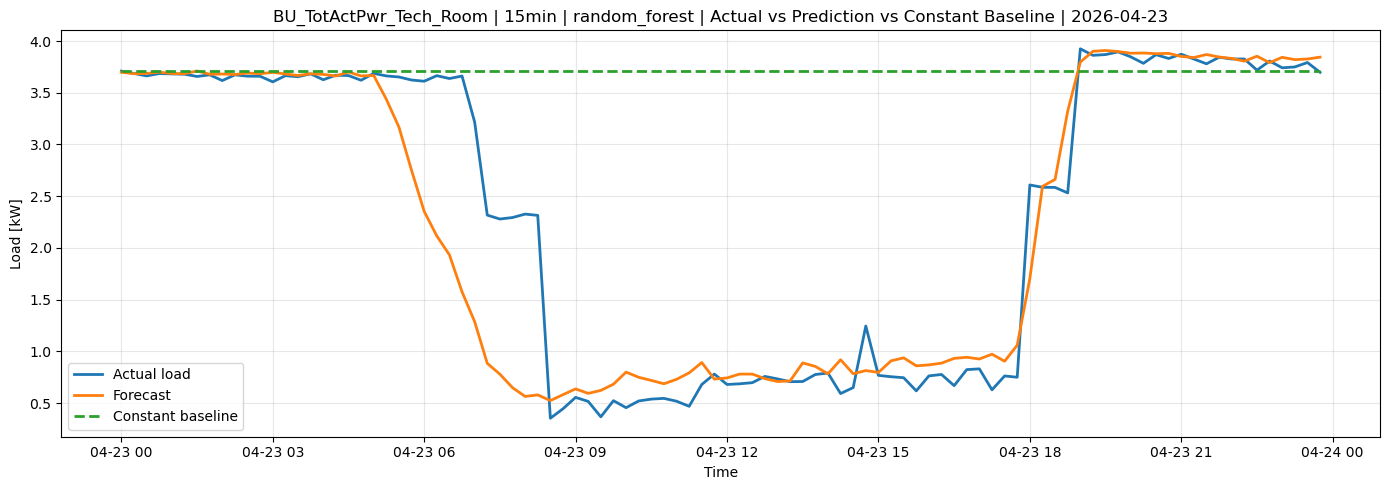

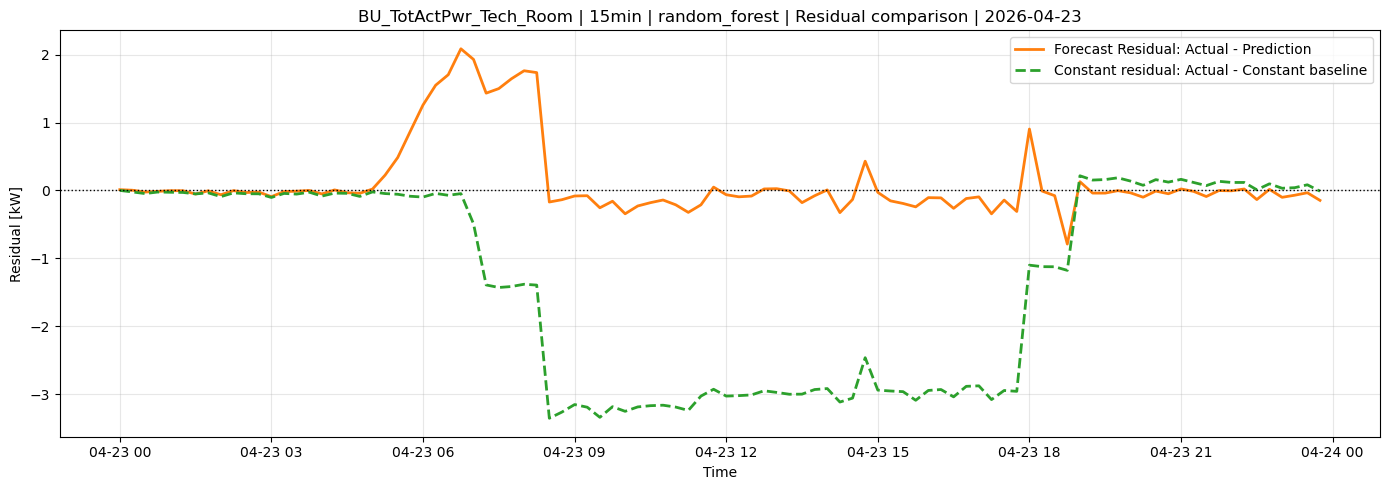

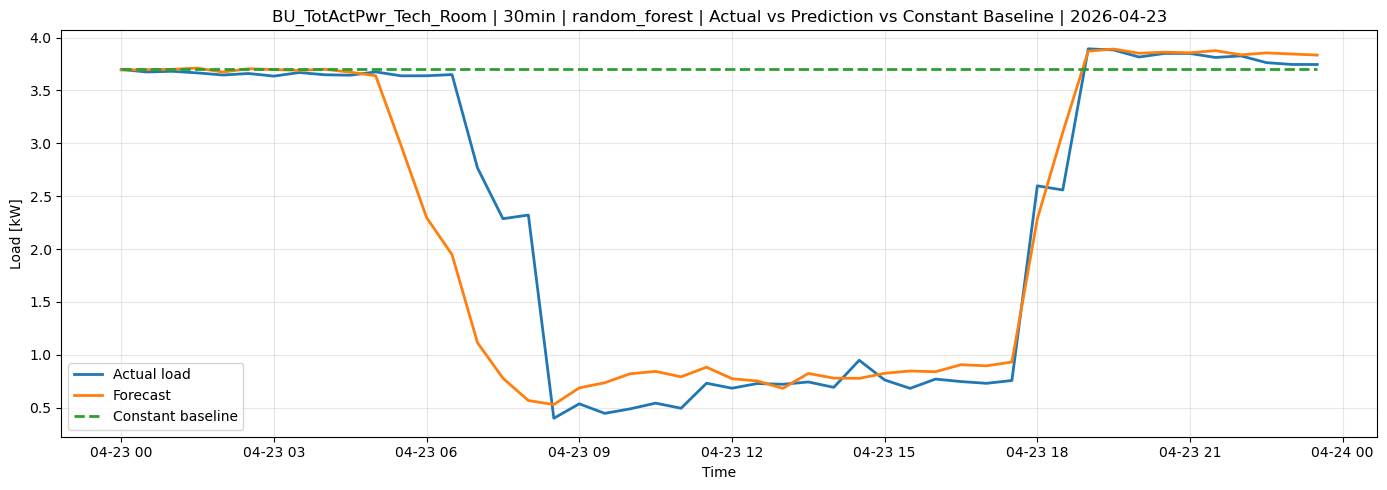

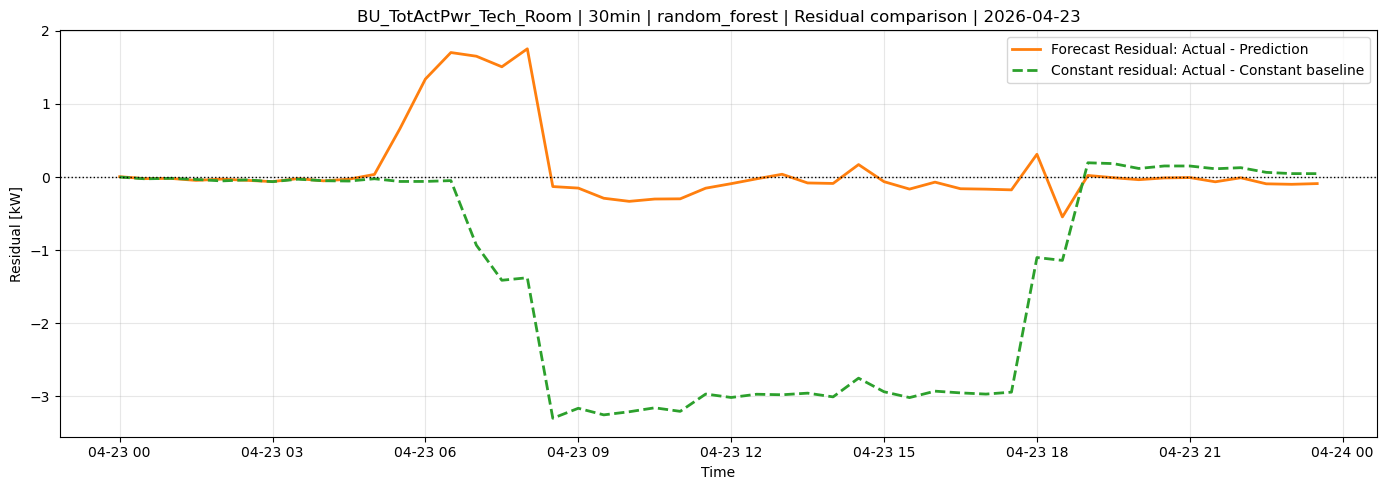

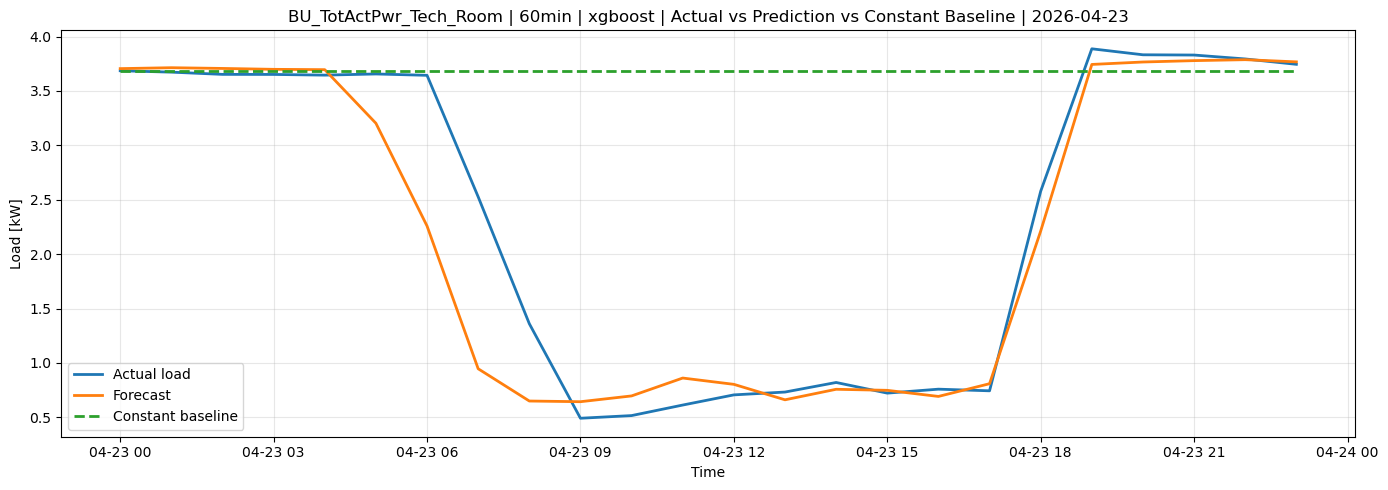

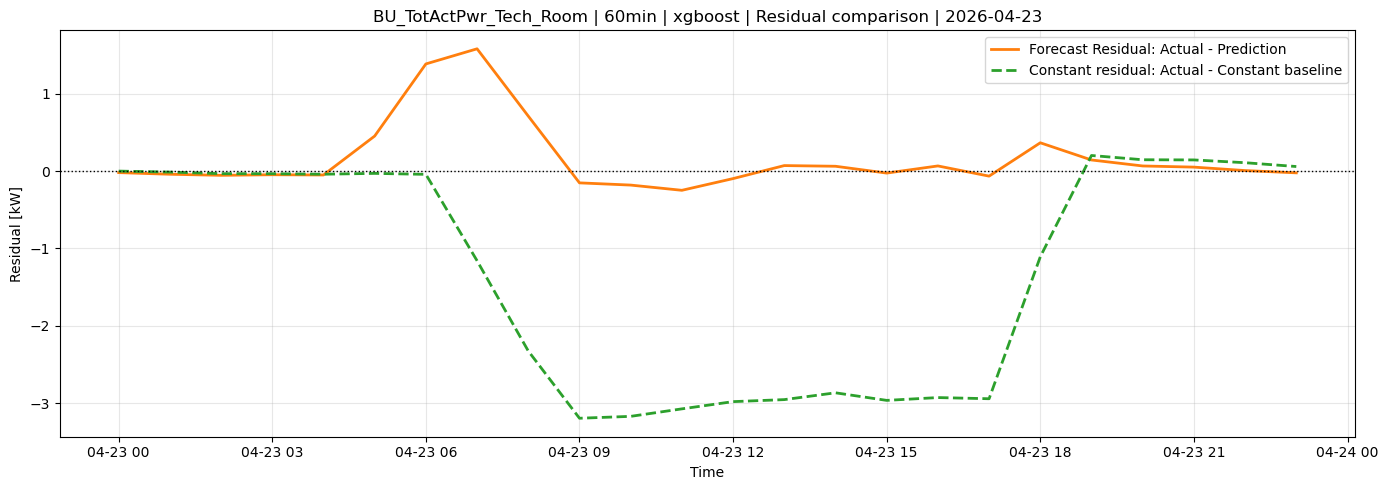

In [54]:
for _, best_row in best_each_resolution.iterrows():
    plot_forecast_and_residuals(
        best_row=best_row,
        pred_dir=pred_dir,
        forecast_date="2026-04-23"
    )

### Select best ML model for each resolution during common dates

In [55]:
best_model_each_resolution_common = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values(["resolution", "mean_ml_absolute_energy_error_kWh"])
    .groupby("resolution", as_index=False)
    .first()
)

display(best_model_each_resolution_common)

,resolution,model_name,file_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
0,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,9,58.106232,55.353108,90.743120,2.753124,-32.636888,7.459176,12.808193,33.294782,57.338506,25.835606,77.390772,0.114713,-1.359870
1,30min,random_forest,run_20260527_102550_662ba0ff_random_forest_BU_...,9,58.080091,55.520197,90.757307,2.559894,-32.677216,6.898038,11.853753,33.223860,57.248999,26.325822,79.056137,0.106662,-1.361551
2,60min,xgboost,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,9,58.073656,54.791928,90.179760,3.281727,-32.106104,6.563000,11.283821,32.685582,56.331646,26.122582,79.770657,0.136739,-1.337754


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def sort_horizon_columns(cols):
    def horizon_number(col):
        base = col.replace("_true", "").replace("_pred", "")
        nums = [p for p in base.split("_") if p.isdigit()]
        return int(nums[-1]) if nums else 999999

    return sorted(cols, key=horizon_number)


def get_dt_hours_from_resolution(resolution):
    if resolution == "15min":
        return 0.25
    if resolution == "30min":
        return 0.5
    if resolution == "60min":
        return 1.0
    raise ValueError(f"Unknown resolution: {resolution}")


def plot_common_day_best_resolution(best_row, pred_dir, forecast_date):
    file_path = pred_dir / best_row["file_name"]

    resolution = best_row["resolution"]
    model_name = best_row["model_name"]
    dt_hours = get_dt_hours_from_resolution(resolution)

    load_name = best_row.get("target_col", target_col)

    df = pd.read_csv(file_path)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sort_horizon_columns([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    forecast_date = pd.to_datetime(forecast_date).date()

    row_df = df[df["forecast_date"] == forecast_date].copy()

    if row_df.empty:
        print(f"No forecast found for {forecast_date} | {resolution} | {model_name}")
        return

    r = row_df.iloc[0]

    y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
    y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

    constant_load = y_true[0]
    y_constant = np.full_like(y_true, constant_load)

    valid = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

    y_true = y_true[valid]
    y_pred = y_pred[valid]
    y_constant = y_constant[valid]

    ml_residual = y_true - y_pred
    constant_residual = y_true - y_constant

    issue_time = r["issue_time"]
    step_minutes = int(dt_hours * 60)

    horizon_times = pd.date_range(
        start=issue_time + pd.Timedelta(minutes=step_minutes),
        periods=len(y_true),
        freq=f"{step_minutes}min"
    )

    actual_color = "tab:blue"
    ml_color = "tab:orange"
    constant_color = "tab:green"

    # ==============================
    # Plot 1: Actual vs ML vs Constant
    # ==============================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        y_true,
        label="Actual load",
        color=actual_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_pred,
        label="ML prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_constant,
        label="Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.title(
        f"{load_name} | {resolution} | {model_name} | "
        f"Actual vs ML Prediction vs Constant Baseline | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Load [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==============================
    # Plot 2: Residuals
    # ==============================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        ml_residual,
        label="ML residual: Actual - ML prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        constant_residual,
        label="Constant residual: Actual - Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"{load_name} | {resolution} | {model_name} | "
        f"Residual comparison | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Residual [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Plotting common forecast date: 2026-04-22


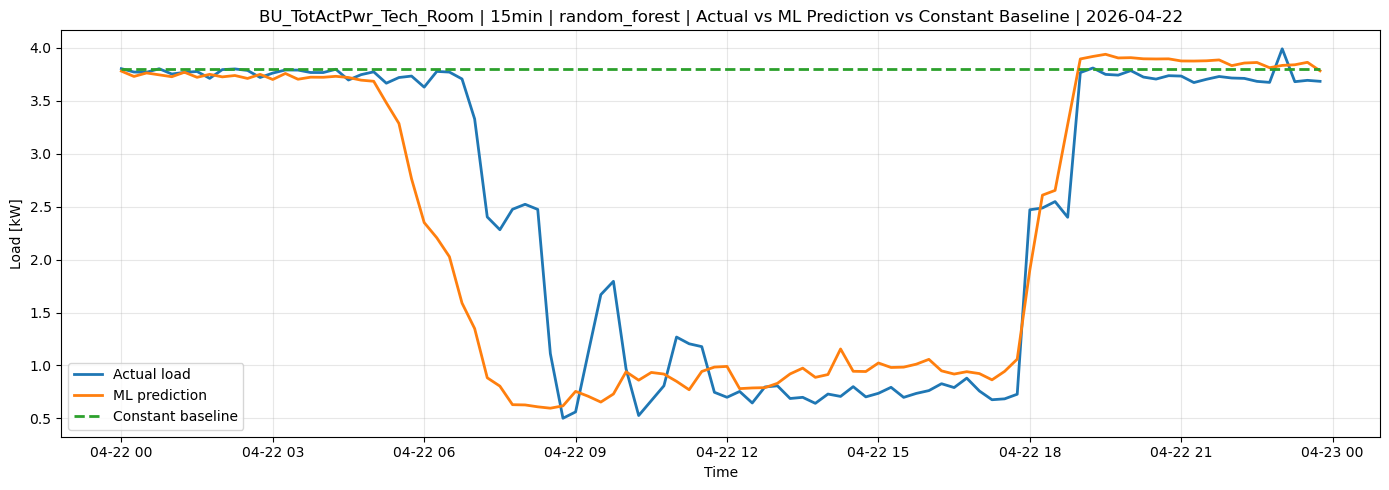

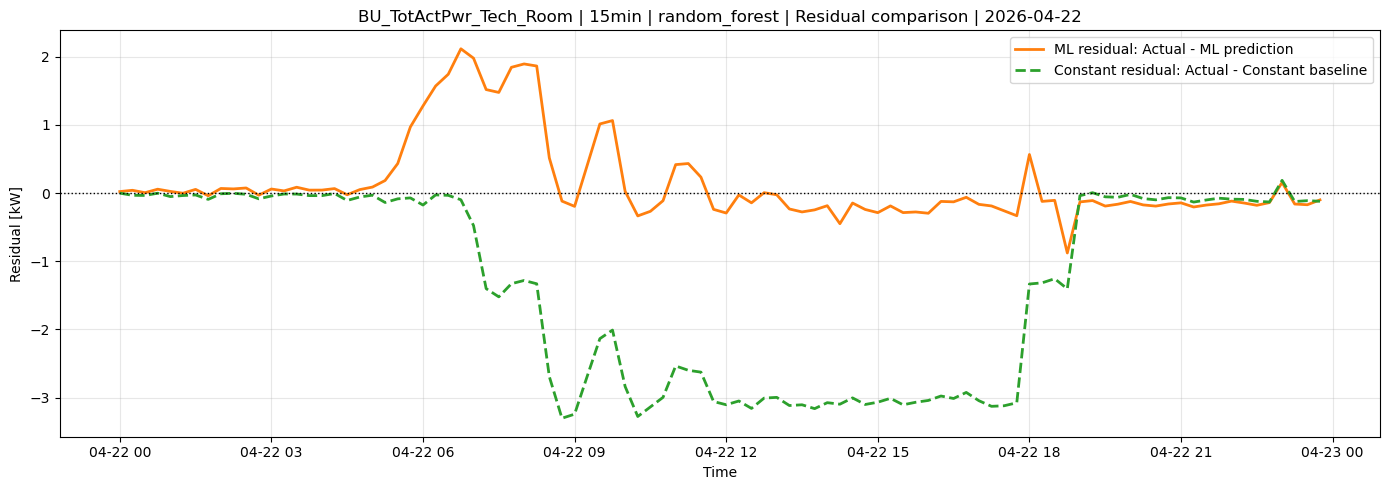

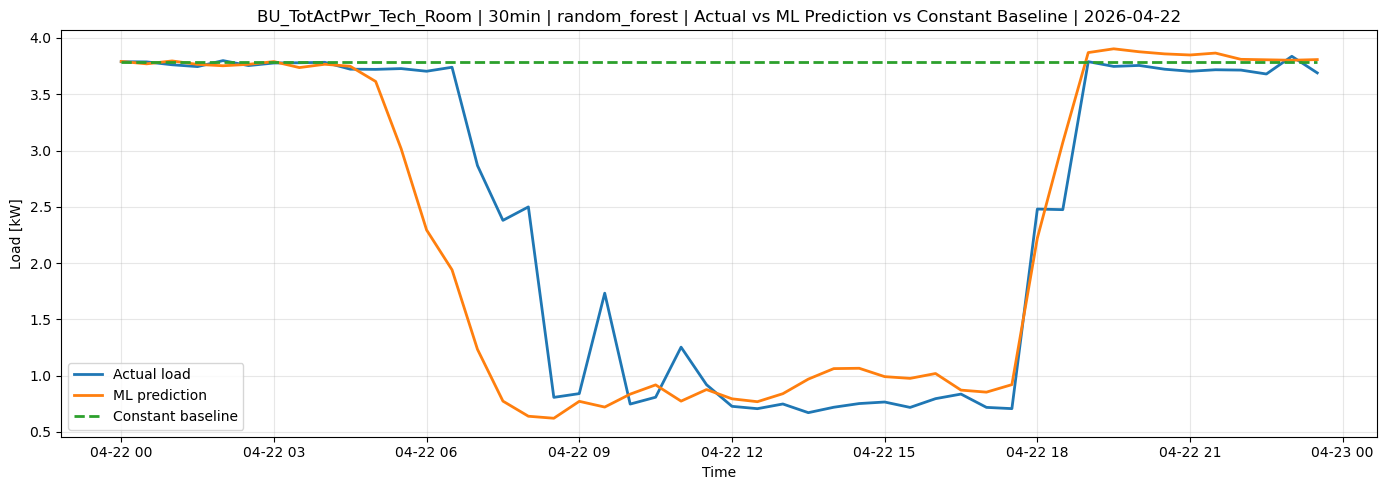

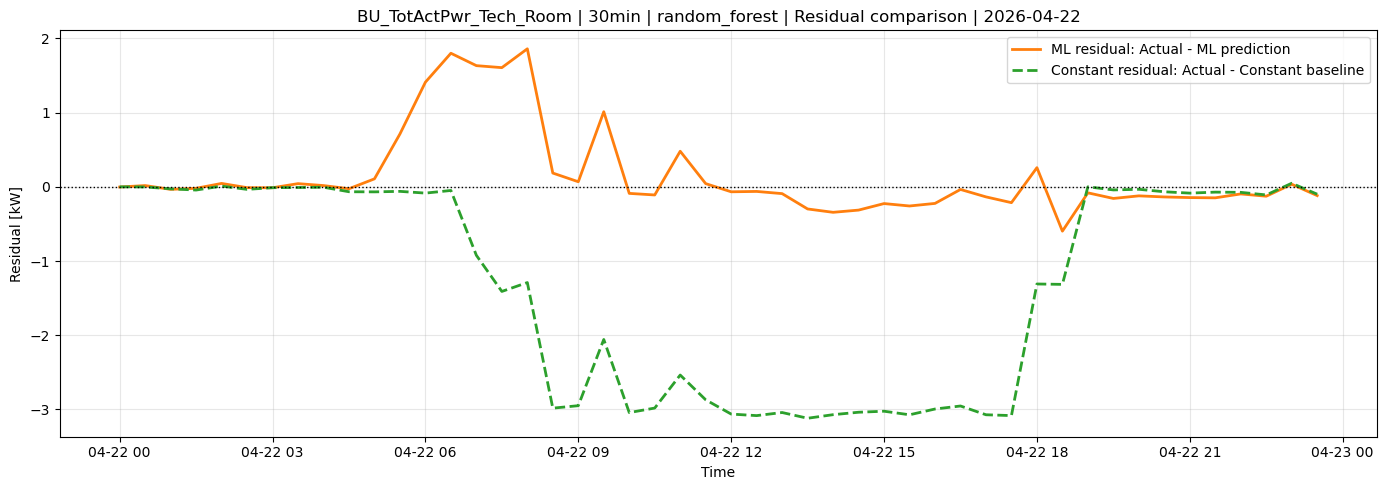

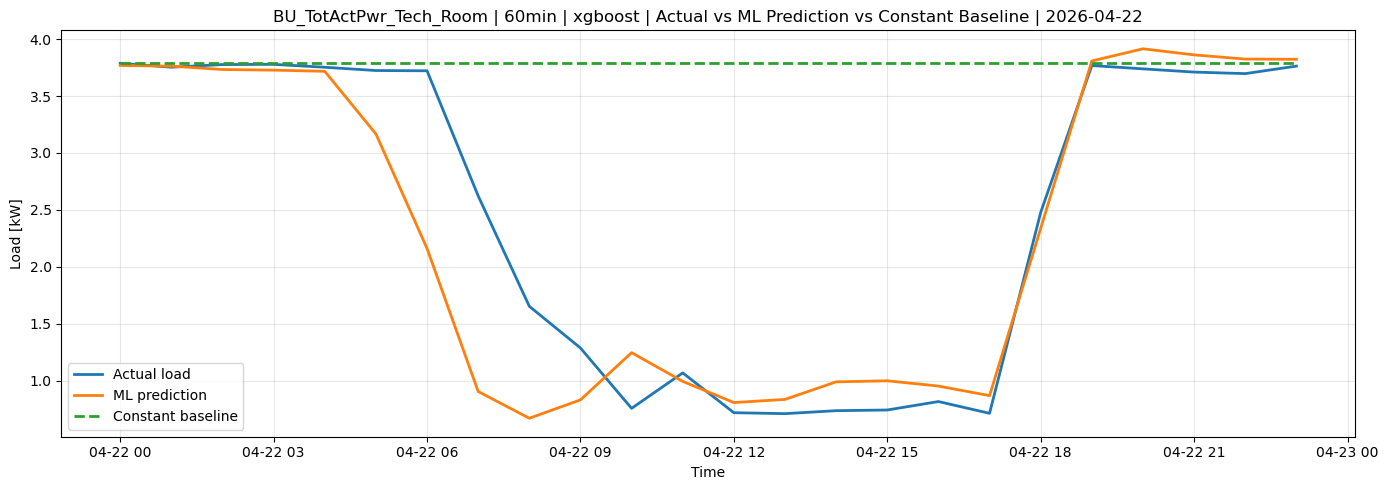

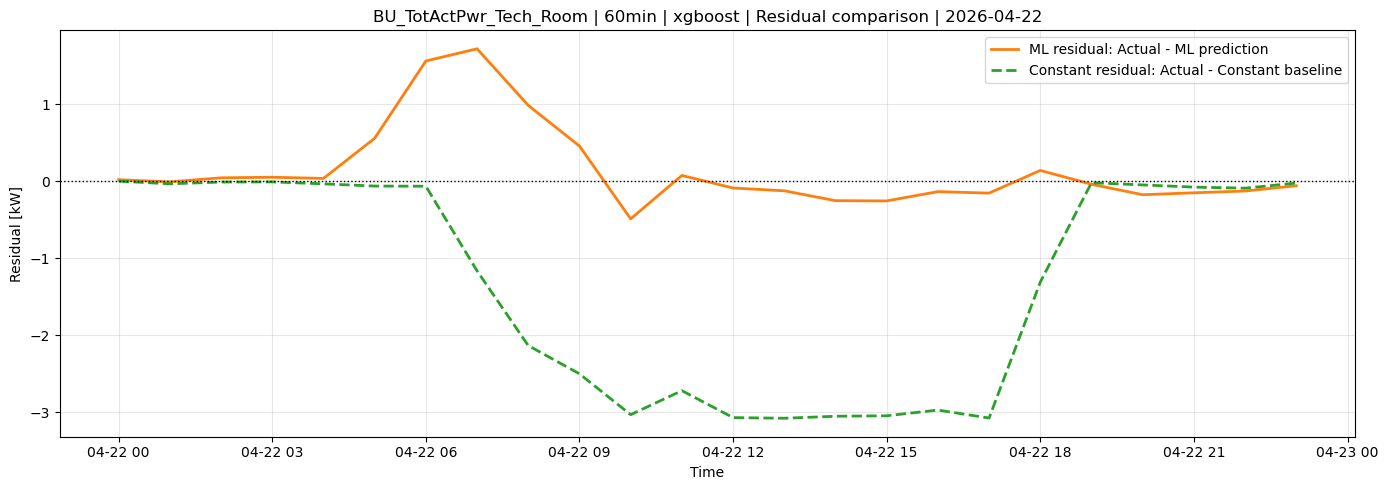

In [57]:
plot_date = common_dates[0]

print("Plotting common forecast date:", plot_date)

for _, best_row in best_model_each_resolution_common.iterrows():
    plot_common_day_best_resolution(
        best_row=best_row,
        pred_dir=pred_dir,
        forecast_date=plot_date
    )

In [58]:
final_common_resolution_comparison = best_model_each_resolution_common[
    [
        "resolution",
        "model_name",
        "n_common_days",

        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",

        "mean_ml_signed_energy_error_kWh",
        "mean_constant_signed_energy_error_kWh",

        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",

        "mean_constant_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_percent",

        "mean_ml_improvement_vs_constant_kWh",
        "mean_ml_improvement_vs_constant_percent",

        "mean_ml_residual_kW",
        "mean_constant_residual_kW",

        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(final_common_resolution_comparison)

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW,file_name
2,60min,xgboost,9,58.073656,54.791928,90.179760,3.281727,-32.106104,6.563000,11.283821,32.685582,56.331646,26.122582,79.770657,0.136739,-1.337754,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...
1,30min,random_forest,9,58.080091,55.520197,90.757307,2.559894,-32.677216,6.898038,11.853753,33.223860,57.248999,26.325822,79.056137,0.106662,-1.361551,run_20260527_102550_662ba0ff_random_forest_BU_...
0,15min,random_forest,9,58.106232,55.353108,90.743120,2.753124,-32.636888,7.459176,12.808193,33.294782,57.338506,25.835606,77.390772,0.114713,-1.359870,run_20260521_105037_ca9fc1b2_random_forest_BU_...


In [59]:
import matplotlib.pyplot as plt
import numpy as np


# Final summary table for plotting
energy_bar_summary = best_model_each_resolution_common.copy()

energy_bar_summary = energy_bar_summary.sort_values("resolution")

display(energy_bar_summary[
    [
        "resolution",
        "model_name",
        "n_common_days",
        "mean_ml_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_kWh",
        "mean_ml_improvement_vs_constant_percent",
    ]
])


,resolution,model_name,n_common_days,mean_ml_absolute_energy_error_kWh,mean_constant_absolute_energy_error_kWh,mean_ml_improvement_vs_constant_percent
0,15min,random_forest,9,7.459176,33.294782,77.390772
1,30min,random_forest,9,6.898038,33.223860,79.056137
2,60min,xgboost,9,6.563000,32.685582,79.770657


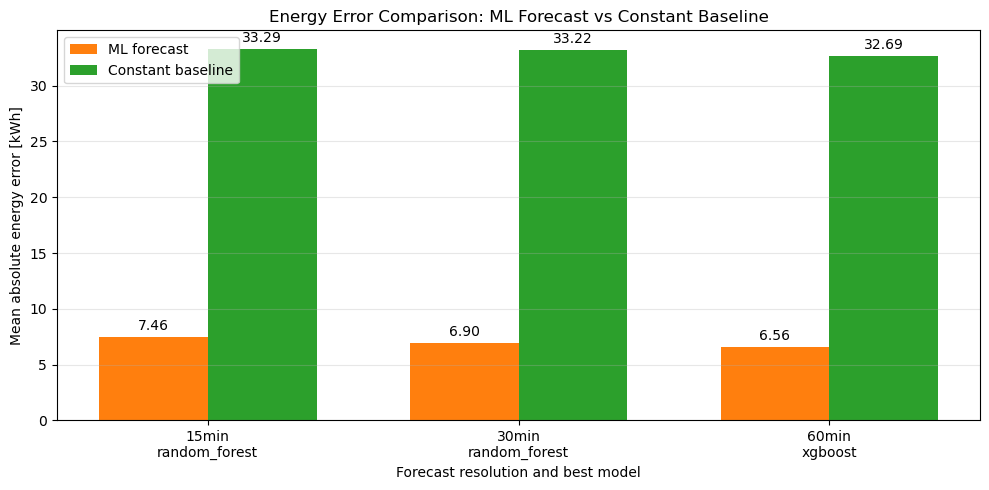

In [60]:
def add_bar_labels(ax, fmt="{:.2f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3)


x = np.arange(len(energy_bar_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    energy_bar_summary["mean_ml_absolute_energy_error_kWh"],
    width,
    label="ML forecast",
    color="tab:orange"
)

ax.bar(
    x + width / 2,
    energy_bar_summary["mean_constant_absolute_energy_error_kWh"],
    width,
    label="Constant baseline",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    energy_bar_summary["resolution"] + "\n" + energy_bar_summary["model_name"]
)

ax.set_ylabel("Mean absolute energy error [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Energy Error Comparison: ML Forecast vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh
0,15min,random_forest,9,58.106232,55.353108,90.743120
1,30min,random_forest,9,58.080091,55.520197,90.757307
2,60min,xgboost,9,58.073656,54.791928,90.179760


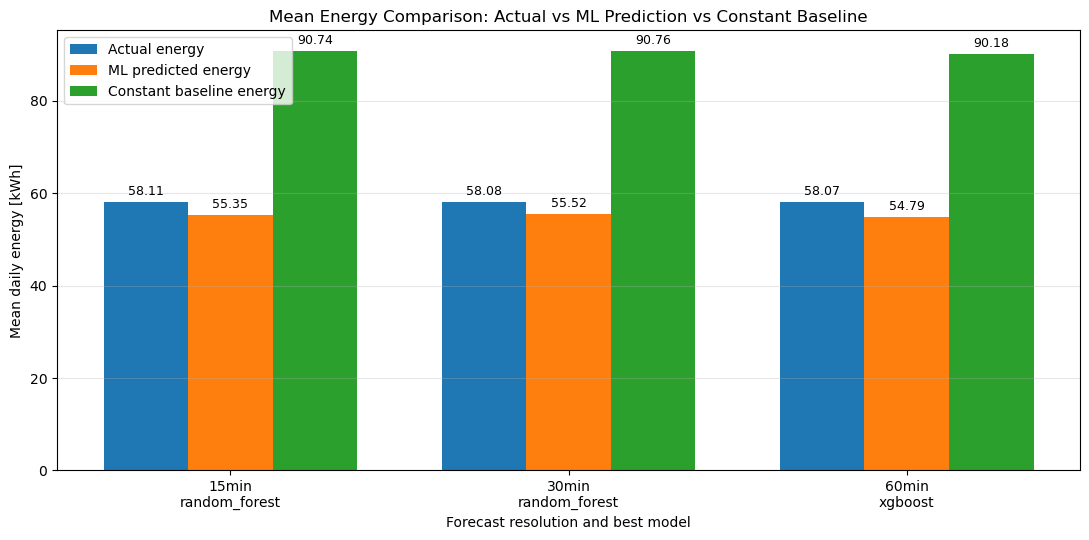

In [61]:
import numpy as np
import matplotlib.pyplot as plt


# Use the best model for each resolution on common forecast dates
energy_total_summary = best_model_each_resolution_common.copy()

# Optional: order resolutions correctly
resolution_order = {"15min": 0, "30min": 1, "60min": 2}
energy_total_summary["resolution_order"] = energy_total_summary["resolution"].map(resolution_order)
energy_total_summary = energy_total_summary.sort_values("resolution_order").reset_index(drop=True)

display(energy_total_summary[
    [
        "resolution",
        "model_name",
        "n_common_days",
        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",
    ]
])


def add_bar_labels(ax, fmt="{:.2f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)


x = np.arange(len(energy_total_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width,
    energy_total_summary["mean_actual_energy_kWh"],
    width,
    label="Actual energy",
    color="tab:blue"
)

ax.bar(
    x,
    energy_total_summary["mean_ml_predicted_energy_kWh"],
    width,
    label="ML predicted energy",
    color="tab:orange"
)

ax.bar(
    x + width,
    energy_total_summary["mean_constant_energy_kWh"],
    width,
    label="Constant baseline energy",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    energy_total_summary["resolution"] + "\n" + energy_total_summary["model_name"]
)

ax.set_ylabel("Mean daily energy [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Mean Energy Comparison: Actual vs ML Prediction vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

### total energy over all common days

,resolution,model_name,file_name,n_common_days,total_actual_energy_kWh,total_ml_predicted_energy_kWh,total_constant_energy_kWh,resolution_order
0,15min,random_forest,run_20260521_105037_ca9fc1b2_random_forest_BU_...,9,522.956089,498.177976,816.68808,0
1,30min,random_forest,run_20260527_102550_662ba0ff_random_forest_BU_...,9,522.720820,499.681776,816.81576,1
2,60min,xgboost,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,9,522.662900,493.127354,811.61784,2


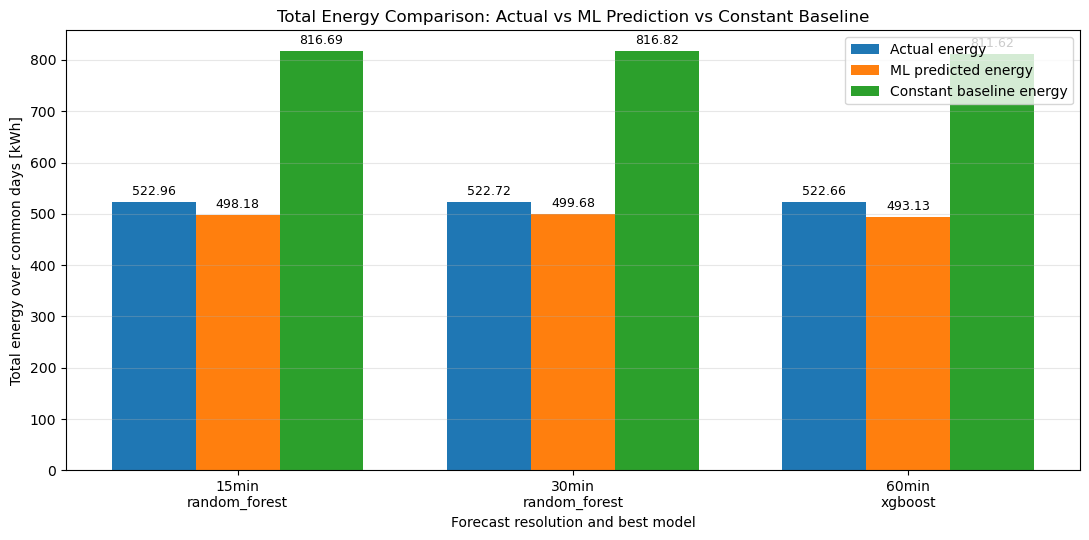

In [62]:
total_energy_summary = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),
        total_actual_energy_kWh=("actual_energy_kWh", "sum"),
        total_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "sum"),
        total_constant_energy_kWh=("constant_energy_kWh", "sum"),
    )
)

# Keep only the best files selected earlier
total_energy_summary = total_energy_summary.merge(
    best_model_each_resolution_common[["resolution", "model_name", "file_name"]],
    on=["resolution", "model_name", "file_name"],
    how="inner"
)

resolution_order = {"15min": 0, "30min": 1, "60min": 2}
total_energy_summary["resolution_order"] = total_energy_summary["resolution"].map(resolution_order)
total_energy_summary = total_energy_summary.sort_values("resolution_order").reset_index(drop=True)

display(total_energy_summary)


x = np.arange(len(total_energy_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width,
    total_energy_summary["total_actual_energy_kWh"],
    width,
    label="Actual energy",
    color="tab:blue"
)

ax.bar(
    x,
    total_energy_summary["total_ml_predicted_energy_kWh"],
    width,
    label="ML predicted energy",
    color="tab:orange"
)

ax.bar(
    x + width,
    total_energy_summary["total_constant_energy_kWh"],
    width,
    label="Constant baseline energy",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    total_energy_summary["resolution"] + "\n" + total_energy_summary["model_name"]
)

ax.set_ylabel("Total energy over common days [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Total Energy Comparison: Actual vs ML Prediction vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

In [63]:
from pathlib import Path
import pandas as pd


# ============================================================
# SETTINGS
# ============================================================

pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
target_col = "BU_TotActPwr_Tech_Room"


# ============================================================
# FUNCTION TO EXTRACT RUN ID FROM FILE NAME
# ============================================================

def extract_run_id(file_name):
    """
    Example:
    run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv

    run_id:
    run_20260521_105037_ca9fc1b2
    """
    parts = file_name.split("_")
    return "_".join(parts[:4])


# ============================================================
# CLEAN ERROR SUMMARY
# ============================================================

error_summary_clean = error_summary.copy()

# Remove invalid/unknown rows
error_summary_clean = error_summary_clean[
    error_summary_clean["resolution"].isin(["15min", "30min", "60min"])
].copy()

error_summary_clean = error_summary_clean[
    error_summary_clean["model_name"] != "unknown"
].copy()

# Add run id and full prediction path
error_summary_clean["run_id"] = error_summary_clean["file_name"].apply(extract_run_id)
error_summary_clean["prediction_path"] = error_summary_clean["file_name"].apply(
    lambda x: str(pred_dir / x)
)


# ============================================================
# BEST MODEL PER RESOLUTION BASED ON LOWEST MAE
# ============================================================

best_model_each_resolution = (
    error_summary_clean
    .sort_values(["resolution", "MAE"])
    .groupby("resolution", as_index=False)
    .first()
)

# Optional: order resolution properly
resolution_order = {"15min": 0, "30min": 1, "60min": 2}
best_model_each_resolution["resolution_order"] = (
    best_model_each_resolution["resolution"].map(resolution_order)
)

best_model_each_resolution = (
    best_model_each_resolution
    .sort_values("resolution_order")
    .drop(columns=["resolution_order"])
    .reset_index(drop=True)
)


# ============================================================
# FINAL TABLE TO DISPLAY
# ============================================================

best_model_paths_table = best_model_each_resolution[
    [
        "resolution",
        "model_name",
        "run_id",
        "target_col",
        "first_forecast_date",
        "last_forecast_date",
        "n_forecast_days",
        "n_issue_times",
        "n_horizon_steps",
        "MAE",
        "RMSE",
        "MAPE_%",
        "R2",
        "bias_actual_minus_pred",
        "error_std",
        "file_name",
        "prediction_path",
    ]
].copy()

display(best_model_paths_table)

,resolution,model_name,run_id,target_col,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std,file_name,prediction_path
0,15min,random_forest,run_20260521_105037_ca9fc1b2,BU_TotActPwr_Tech_Room,2026-04-20,2026-04-30,11,11,96,0.310727,0.572254,20.242668,0.838095,0.116292,0.560313,run_20260521_105037_ca9fc1b2_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,30min,random_forest,run_20260527_102550_662ba0ff,BU_TotActPwr_Tech_Room,2026-04-22,2026-04-30,9,9,48,0.287418,0.531768,18.337919,0.858043,0.106662,0.520961,run_20260527_102550_662ba0ff_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,60min,xgboost,run_20260513_094936_b3ae2d0e,BU_TotActPwr_Tech_Room,2026-04-21,2026-04-30,10,10,24,0.275025,0.505873,17.564096,0.868779,0.149611,0.483243,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [64]:
best_energy_model_paths_table = best_model_each_resolution_common.copy()

best_energy_model_paths_table["run_id"] = best_energy_model_paths_table["file_name"].apply(extract_run_id)
best_energy_model_paths_table["prediction_path"] = best_energy_model_paths_table["file_name"].apply(
    lambda x: str(pred_dir / x)
)

best_energy_model_paths_table = best_energy_model_paths_table[
    [
        "resolution",
        "model_name",
        "run_id",
        "n_common_days",
        "prediction_path",
    ]
]

display(best_energy_model_paths_table)

,resolution,model_name,run_id,n_common_days,prediction_path
0,15min,random_forest,run_20260521_105037_ca9fc1b2,9,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,30min,random_forest,run_20260527_102550_662ba0ff,9,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,60min,xgboost,run_20260513_094936_b3ae2d0e,9,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [65]:
from pathlib import Path

pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")

best_prediction_paths = [
    str(pred_dir / file_name)
    for file_name in best_model_each_resolution_common["file_name"]
]

for path in best_prediction_paths:
    print(path)

C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_102550_662ba0ff_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260513_094936_b3ae2d0e_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv


In [67]:
from pathlib import Path
import pandas as pd
from datetime import datetime


pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
registry_path = pred_dir.parent / "best_prediction_files_registry.csv"


def extract_run_id(file_name):
    parts = file_name.split("_")
    return "_".join(parts[:4])


def extract_target_col_from_file_name(file_name, model_name):
    """
    Example:
    run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv

    Returns:
    BU_TotActPwr_Tech_Room
    """

    name = file_name.replace("_profile_predictions.csv", "")

    run_id = extract_run_id(file_name)

    # Remove run_id part
    remaining = name.replace(run_id + "_", "")

    # Remove model name part
    remaining = remaining.replace(model_name + "_", "", 1)

    return remaining


current_best_paths = best_model_each_resolution_common.copy()

current_best_paths["run_id"] = current_best_paths["file_name"].apply(extract_run_id)

current_best_paths["target_col"] = current_best_paths.apply(
    lambda row: extract_target_col_from_file_name(
        row["file_name"],
        row["model_name"]
    ),
    axis=1
)

current_best_paths["prediction_path"] = current_best_paths["file_name"].apply(
    lambda x: str(pred_dir / x)
)

current_best_paths["registry_added_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


wanted_cols = [
    "registry_added_at",
    "target_col",
    "resolution",
    "model_name",
    "run_id",
    "file_name",
    "prediction_path",
    "n_common_days",
    "mean_actual_energy_kWh",
    "mean_ml_predicted_energy_kWh",
    "mean_constant_energy_kWh",
    "mean_ml_absolute_energy_error_kWh",
    "mean_ml_absolute_energy_error_percent",
    "mean_constant_absolute_energy_error_kWh",
    "mean_constant_absolute_energy_error_percent",
    "mean_ml_improvement_vs_constant_percent",
]

current_best_paths = current_best_paths[
    [c for c in wanted_cols if c in current_best_paths.columns]
].copy()


if registry_path.exists():
    registry = pd.read_csv(registry_path)
    registry = pd.concat([registry, current_best_paths], ignore_index=True)
else:
    registry = current_best_paths.copy()


duplicate_key_cols = [
    "target_col",
    "resolution",
    "model_name",
    "run_id",
    "file_name",
    "prediction_path",
]

registry = registry.drop_duplicates(
    subset=[c for c in duplicate_key_cols if c in registry.columns],
    keep="first"
).copy()


resolution_order = {"15min": 0, "30min": 1, "60min": 2}
registry["resolution_order"] = registry["resolution"].map(resolution_order)

registry = (
    registry
    .sort_values(["target_col", "resolution_order", "registry_added_at"])
    .drop(columns=["resolution_order"])
    .reset_index(drop=True)
)

registry.to_csv(registry_path, index=False)

print("Registry saved/updated:")
print(registry_path)

display(registry)

Registry saved/updated:
C:\Data_analysis\Thesis\outputs\profile_forecasting\best_prediction_files_registry.csv


,registry_added_at,target_col,resolution,model_name,run_id,file_name,prediction_path,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_percent
0,2026-05-29 13:43:08,BU_TotActPwr_Academy,15min,xgboost,run_20260512_171555_4d7cc794,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.565797,158.376672,88.996980,29.558080,20.477633,74.282828,43.938212,29.744413
1,2026-05-29 13:43:08,BU_TotActPwr_Academy,30min,random_forest,run_20260526_154855_5f504912,run_20260526_154855_5f504912_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.527170,178.946263,90.357030,38.487983,27.410292,72.994736,43.148351,-3.342269
2,2026-05-29 13:43:08,BU_TotActPwr_Academy,60min,random_forest,run_20260521_093016_89fcbb0f,run_20260521_093016_89fcbb0f_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.515481,164.015870,88.651500,34.576039,25.591586,73.225176,43.307650,-2.266626
3,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,15min,random_forest,run_20260521_105037_ca9fc1b2,run_20260521_105037_ca9fc1b2_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.106232,55.353108,90.743120,7.459176,12.808193,33.294782,57.338506,77.390772
4,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,30min,random_forest,run_20260527_102550_662ba0ff,run_20260527_102550_662ba0ff_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.080091,55.520197,90.757307,6.898038,11.853753,33.223860,57.248999,79.056137
5,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,60min,xgboost,run_20260513_094936_b3ae2d0e,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.073656,54.791928,90.179760,6.563000,11.283821,32.685582,56.331646,79.770657
